# Weather Data Analysis and Temperature Prediction

This project analyzes historical weather data using Exploratory Data Analysis (EDA) and predicts daily mean temperature using Machine Learning models.

## Objectives
- Analyze weather trends
- Perform feature engineering
- Compare regression models
- Predict future temperatures

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving DailyDelhiClimateTrain.csv to DailyDelhiClimateTrain (1).csv


In [3]:
df = pd.read_csv("DailyDelhiClimateTrain.csv")

In [4]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [6]:
df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


In [10]:
df.isnull().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [9]:
df["date"] = pd.to_datetime(df["date"])

In [11]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [12]:
df["Year"] = df["date"].dt.year
df["Month"] = df["date"].dt.month
df["Day"] = df["date"].dt.day

In [13]:
df.drop("date", axis=1, inplace=True)

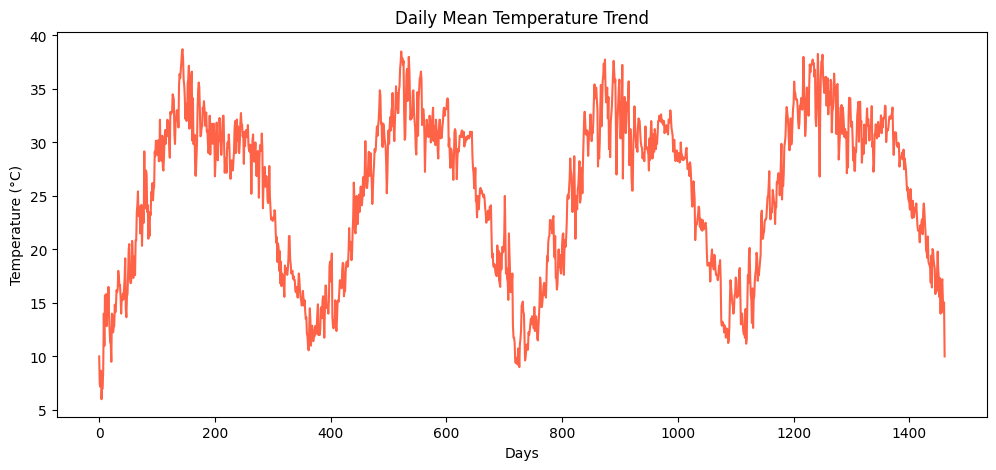

In [25]:
plt.figure(figsize=(12,5))

plt.plot(df["meantemp"], color="tomato")

plt.title("Daily Mean Temperature Trend")
plt.xlabel("Days")
plt.ylabel("Temperature (°C)")

plt.show()

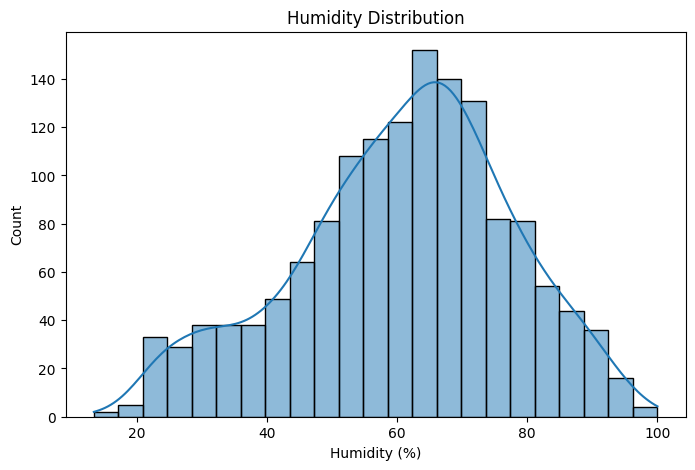

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df["humidity"], kde=True)

plt.title("Humidity Distribution")
plt.xlabel("Humidity (%)")

plt.show()

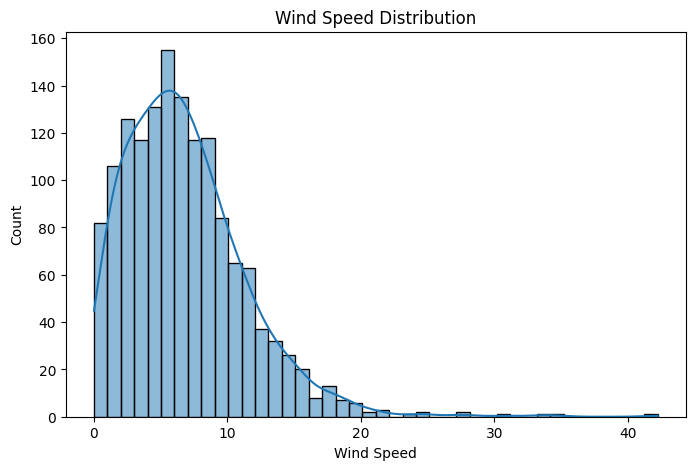

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df["wind_speed"], kde=True)

plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed")

plt.show()

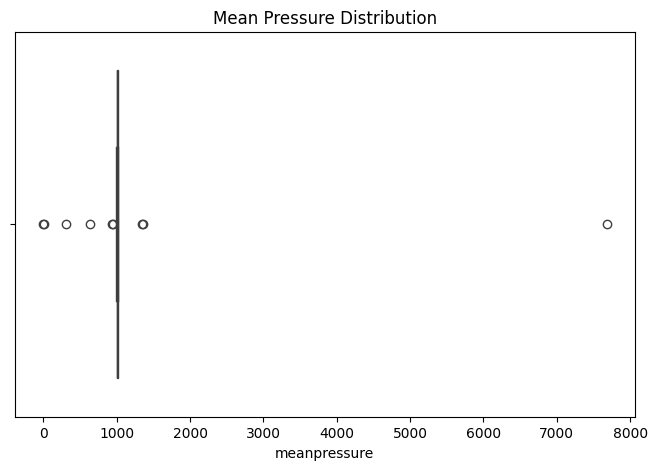

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["meanpressure"])

plt.title("Mean Pressure Distribution")

plt.show()

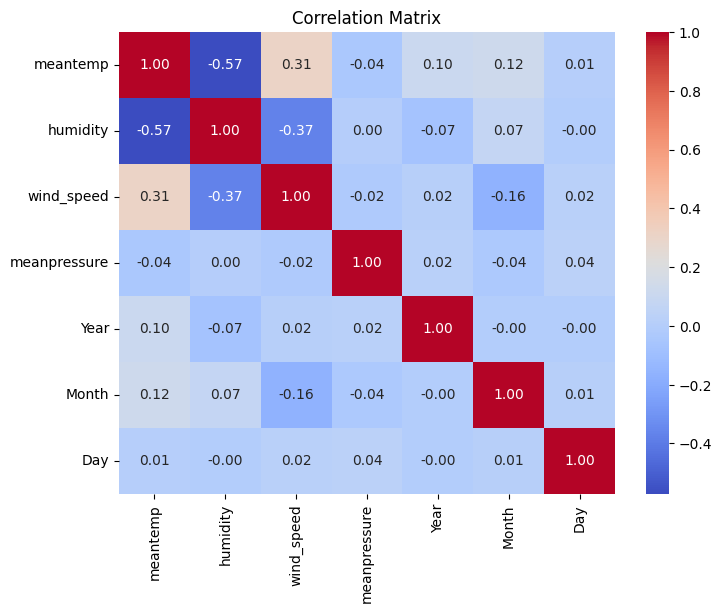

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

In [30]:
y = df["meantemp"]

In [31]:
X = df.drop("meantemp", axis=1)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [34]:
pred = lr.predict(X_test)

In [35]:
print("MAE :", mean_absolute_error(y_test, pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))

print("R2 :", r2_score(y_test, pred))

MAE : 4.98184386036068
RMSE : 6.068095704354469
R2 : 0.3150638218997368


In [36]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [37]:
pred_rf = rf.predict(X_test)

In [38]:
print(mean_absolute_error(y_test, pred_rf))

print(np.sqrt(mean_squared_error(y_test, pred_rf)))

print(r2_score(y_test, pred_rf))

1.2717340158306982
1.779560684069874
0.9410924626613965


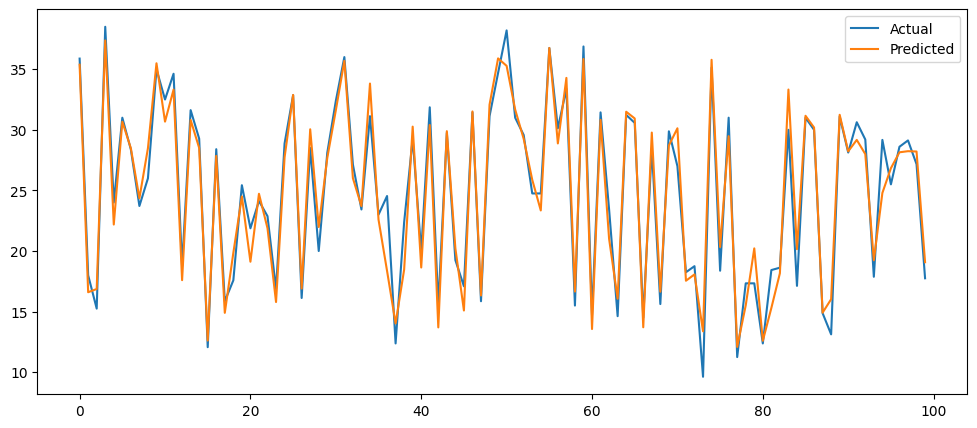

In [39]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:100], label="Actual")

plt.plot(pred_rf[:100], label="Predicted")

plt.legend()

plt.show()

<Axes: >

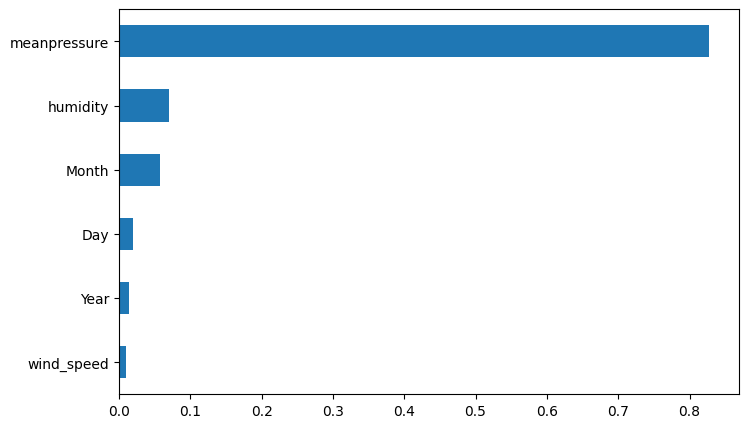

In [40]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot.barh(figsize=(8,5))

In [41]:
import joblib

joblib.dump(rf, "weather_prediction.pkl")

['weather_prediction.pkl']

In [42]:
model = joblib.load("weather_prediction.pkl")

In [43]:
sample = X.iloc[[0]]

model.predict(sample)

array([10.0637619])

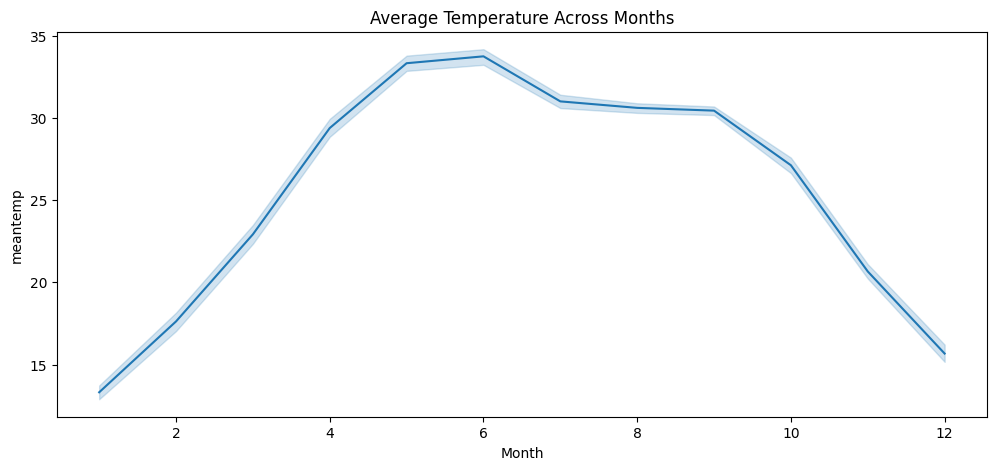

In [44]:
plt.figure(figsize=(12,5))

sns.lineplot(x=df["Month"], y=df["meantemp"])

plt.title("Average Temperature Across Months")
plt.show()

In [45]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, pred),
        mean_absolute_error(y_test, pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred)),
        np.sqrt(mean_squared_error(y_test, pred_rf))
    ],
    "R2 Score": [
        r2_score(y_test, pred),
        r2_score(y_test, pred_rf)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4.981844,6.068096,0.315064
1,Random Forest,1.271734,1.779561,0.941092


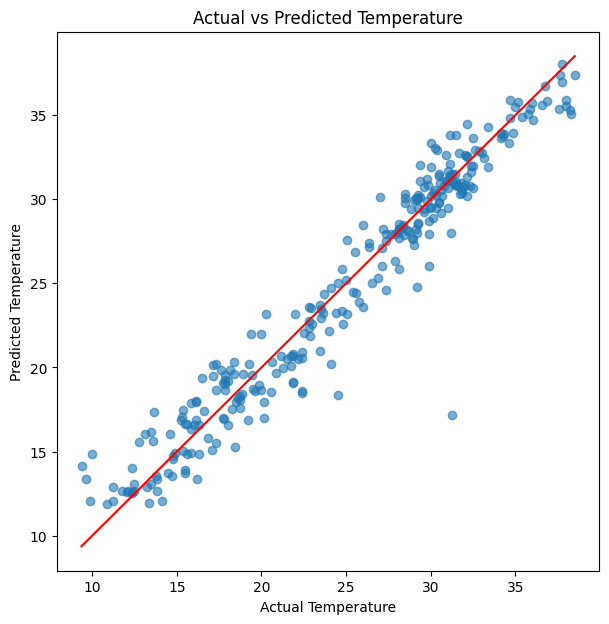

In [46]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, pred_rf, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")

plt.show()

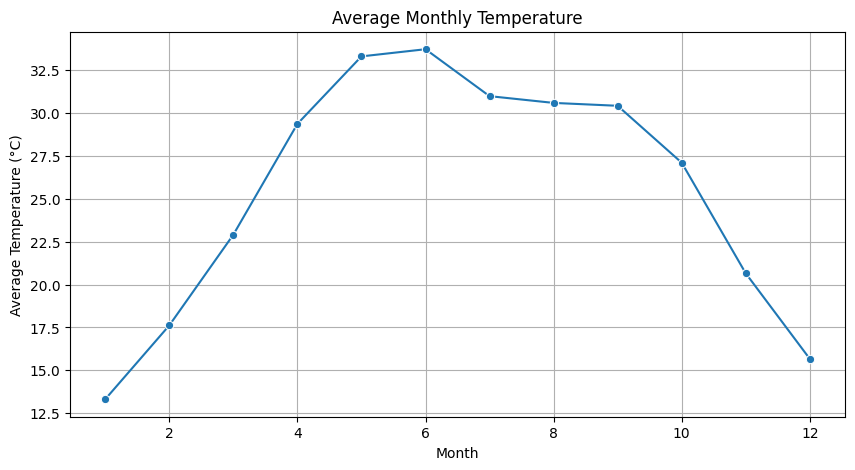

In [47]:
monthly_temp = df.groupby("Month")["meantemp"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_temp,
    x="Month",
    y="meantemp",
    marker="o"
)

plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")

plt.grid(True)

plt.show()

In [48]:
df["7_Day_Avg"] = df["meantemp"].rolling(window=7).mean()

df["30_Day_Avg"] = df["meantemp"].rolling(window=30).mean()

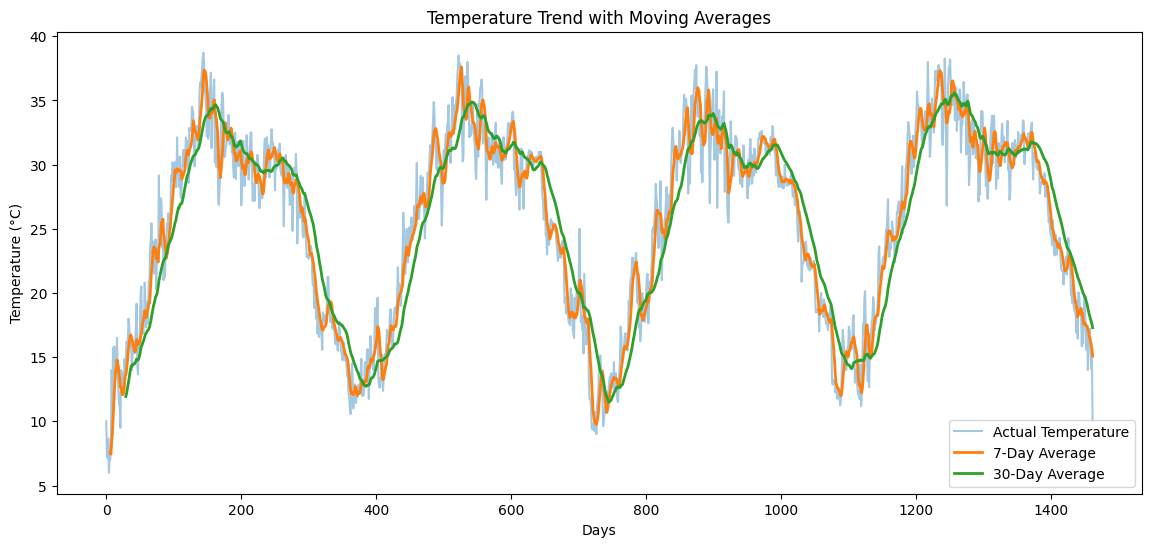

In [49]:
plt.figure(figsize=(14,6))

plt.plot(df["meantemp"], label="Actual Temperature", alpha=0.4)

plt.plot(df["7_Day_Avg"], label="7-Day Average", linewidth=2)

plt.plot(df["30_Day_Avg"], label="30-Day Average", linewidth=2)

plt.title("Temperature Trend with Moving Averages")

plt.xlabel("Days")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.show()

In [50]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, pred),
        mean_absolute_error(y_test, pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred)),
        np.sqrt(mean_squared_error(y_test, pred_rf))
    ],
    "R2 Score": [
        r2_score(y_test, pred),
        r2_score(y_test, pred_rf)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4.981844,6.068096,0.315064
1,Random Forest,1.271734,1.779561,0.941092


In [51]:
sample = pd.DataFrame({
    "humidity": [65],
    "wind_speed": [8],
    "meanpressure": [1015],
    "Year": [2017],
    "Month": [1],
    "Day": [15]
})

prediction = model.predict(sample)

print(f"Predicted Temperature: {prediction[0]:.2f} °C")

Predicted Temperature: 18.01 °C


# Conclusion

- Performed data cleaning and preprocessing.
- Conducted exploratory data analysis (EDA).
- Built and compared Linear Regression and Random Forest models.
- Random Forest achieved the best performance with an R² score of approximately 0.94.
- Saved the trained model for future predictions using Joblib.